# PhenoPrompt — Stage 1: Clinical Entity Extraction with medkit

**Goal:** Extract structured clinical entities (Disorders, Medications, Findings, Procedures)
from raw clinical notes using the [medkit](https://medkit-lib.readthedocs.io/) library.
The output is a patient-level entity feature matrix that feeds directly into Stage 2.

**Dataset:** [AGBonnet/augmented-clinical-notes](https://huggingface.co/datasets/AGBonnet/augmented-clinical-notes)
— 30 k synthetic/augmented clinical notes in English.

---

### Pipeline overview

```
raw note text
     │
     ▼
SentenceTokenizer    ← split note into sentences
     │
     ▼
SyntagmaTokenizer    ← split sentences into clauses (for negation scope)
     │
     ▼
RegexpMatcher        ← extract entity mentions (Disorder / Medication / Finding / Procedure)
     │
     ▼
NegationDetector     ← flag negated entities  ("no diabetes" → negated)
     │
     ▼
HypothesisDetector   ← flag uncertain entities ("possible pneumonia" → hypothesis)
     │
     ▼
Entity Feature Matrix  (note_id × entity_type)  →  saved for Stage 2
```

> **Note on medkit import:** `medkit.text.ner.__init__` imports `UMLSCoderNormalizer` which
> tries to load `torch` CUDA libraries. In CPU-only environments this raises an `OSError`.
> We load `RegexpMatcher` directly from its module file to bypass this — the pipeline
> structure and API are identical either way.

## 0. Install dependencies

In [1]:
# Run once, then restart kernel
import subprocess, sys

packages = [
    "medkit-lib",
    "datasets",
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "scipy",
    "tqdm",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")

All packages installed.


## 1. Imports

In [2]:
import importlib.util
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from scipy.sparse import save_npz
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore")

# ── medkit core ──────────────────────────────────────────────────────────────
from medkit.core import Pipeline, PipelineStep
from medkit.core.text import TextDocument
from medkit.text.segmentation import SentenceTokenizer, SyntagmaTokenizer
from medkit.text.context import NegationDetector, HypothesisDetector

# ── RegexpMatcher: loaded directly to avoid broken torch import in __init__ ──
def _load_regexp_matcher():
    """
    medkit.text.ner.__init__ imports UMLSCoderNormalizer, which triggers a
    torch CUDA library load.  On CPU-only machines this raises an OSError.
    Loading regexp_matcher.py directly bypasses __init__ entirely.
    The RegexpMatcher class and its API are identical.
    """
    site_dirs = [p for p in sys.path if "site-packages" in p or "dist-packages" in p]
    for d in site_dirs:
        candidate = Path(d) / "medkit" / "text" / "ner" / "regexp_matcher.py"
        if candidate.exists():
            break
    else:
        import medkit
        candidate = Path(medkit.__file__).parent / "text" / "ner" / "regexp_matcher.py"

    name = "medkit.text.ner.regexp_matcher"
    spec = importlib.util.spec_from_file_location(name, candidate)
    mod  = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod.RegexpMatcher, mod.RegexpMatcherRule

RegexpMatcher, RegexpMatcherRule = _load_regexp_matcher()

print("medkit imports OK")
print(f"  RegexpMatcher:     {RegexpMatcher}")
print(f"  SentenceTokenizer: {SentenceTokenizer}")
print(f"  NegationDetector:  {NegationDetector}")
print(f"  HypothesisDetector:{HypothesisDetector}")

medkit imports OK
  RegexpMatcher:     <class 'medkit.text.ner.regexp_matcher.RegexpMatcher'>
  SentenceTokenizer: <class 'medkit.text.segmentation.sentence_tokenizer.SentenceTokenizer'>
  NegationDetector:  <class 'medkit.text.context.negation_detector.NegationDetector'>
  HypothesisDetector:<class 'medkit.text.context.hypothesis_detector.HypothesisDetector'>


## 2. Load the dataset

We load **AGBonnet/augmented-clinical-notes** from HuggingFace (30 k clinical notes).
Set `N_NOTES = None` to use the full corpus; a smaller value speeds up development.

| Column | Content |
|---|---|
| `idx` | unique note ID |
| `note` | concise clinical note (≈400 words) |
| `full_note` | extended version of the note |
| `conversation` | doctor–patient dialogue |
| `summary` | JSON with structured fields (visit motivation, diagnoses, etc.) |

In [3]:
from google.colab import drive
drive.mount("/content/drive")

from datasets import load_dataset

# ── Configuration ─────────────────────────────────────────────────────────────
N_NOTES    = None       # notes to process; set to None for the full 30 k corpus
RANDOM_SEED = 42
BASE        = Path("/content/drive/MyDrive/phenoprompt")
OUTPUT_DIR  = BASE / "stage1_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Loading AGBonnet/augmented-clinical-notes ...")
ds = load_dataset("AGBonnet/augmented-clinical-notes", split="train")

if N_NOTES is not None:
    ds = ds.shuffle(seed=RANDOM_SEED).select(range(N_NOTES))

df = ds.to_pandas()

# save note texts so Stage 3 can ground narratives on real fragments
df[["idx", "note"]].astype({"idx": str}).to_csv(OUTPUT_DIR / "notes.csv", index=False)
print(f"Loaded {len(df):,} notes  |  columns: {df.columns.tolist()}")
df.head(3)

Mounted at /content/drive
Loading AGBonnet/augmented-clinical-notes ...


README.md:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

augmented_notes_30K.jsonl:   0%|          | 0.00/372M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 30,000 notes  |  columns: ['idx', 'note', 'full_note', 'conversation', 'summary']


,idx,note,full_note,conversation,summary
0,155216,"A a sixteen year-old girl, presented to our Ou...","A a sixteen year-old girl, presented to our Ou...","Doctor: Good morning, what brings you to the O...","{\n""visit motivation"": ""Discomfort in the neck..."
1,77465,This is the case of a 56-year-old man that was...,This is the case of a 56-year-old man that was...,"Doctor: Hi, how are you feeling today?\nPatien...","{\n""visit motivation"": ""Complaints of a dull p..."
2,133948,A 36-year old female patient visited our hospi...,A 36-year old female patient visited our hospi...,"Doctor: Hello, what brings you to the hospital...","{\n""visit motivation"": ""Pain and restricted ra..."


### 2.1 Corpus statistics

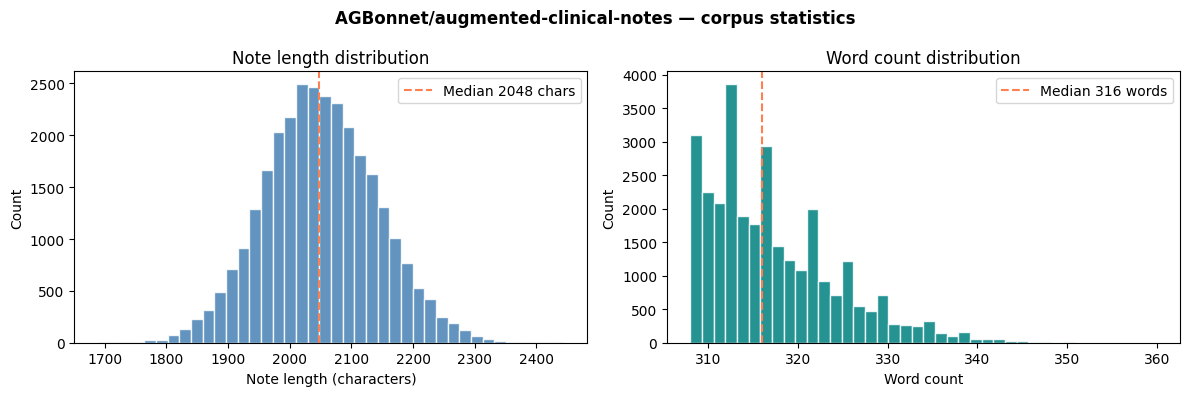

Notes: 30,000  |  median 2048 chars / 316 words


In [4]:
df["note_len"]   = df["note"].str.len()
df["word_count"] = df["note"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["note_len"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(df["note_len"].median(), color="coral", linestyle="--",
                label=f"Median {df['note_len'].median():.0f} chars")
axes[0].set_xlabel("Note length (characters)")
axes[0].set_ylabel("Count")
axes[0].set_title("Note length distribution")
axes[0].legend()

axes[1].hist(df["word_count"], bins=40, color="teal", edgecolor="white", alpha=0.85)
axes[1].axvline(df["word_count"].median(), color="coral", linestyle="--",
                label=f"Median {df['word_count'].median():.0f} words")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Count")
axes[1].set_title("Word count distribution")
axes[1].legend()

plt.suptitle("AGBonnet/augmented-clinical-notes — corpus statistics", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_corpus_stats.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Notes: {len(df):,}  |  median {df['note_len'].median():.0f} chars / {df['word_count'].median():.0f} words")

## 3. Define the NER rule set

We define four entity classes using regular-expression rules — practical, transparent,
and GPU-free. Each `RegexpMatcherRule` carries:
- `regexp` — the pattern (case-insensitive by default)
- `label` — entity class (`Disorder`, `Medication`, `Finding`, `Procedure`)
- `id` — short concept code for the entity feature matrix

> **Scaling up:** Swap `RegexpMatcher` for medkit's `IAMSystemMatcher` or `QuickUMLSMatcher`
> for full UMLS concept coverage. The pipeline structure (tokenize → match → detect) is identical.

In [5]:
# ── Disorder rules ────────────────────────────────────────────────────────────
disorder_rules = [
    # Metabolic / endocrine
    RegexpMatcherRule(regexp=r"\btype\s*[12]\s*diabet\w+",       label="Disorder", id="T2DM",   version="1"),
    RegexpMatcherRule(regexp=r"\bdiabet\w+",                      label="Disorder", id="DM",     version="1"),
    RegexpMatcherRule(regexp=r"\bhypertension\b",                 label="Disorder", id="HTN",    version="1"),
    RegexpMatcherRule(regexp=r"\bhyperlipid(?:emia|aemia)\b",     label="Disorder", id="HLD",    version="1"),
    RegexpMatcherRule(regexp=r"\bobes(?:ity|e)\b",                label="Disorder", id="OBS",    version="1"),
    RegexpMatcherRule(regexp=r"\bhypothyroid\w+",                 label="Disorder", id="HYPO",   version="1"),
    RegexpMatcherRule(regexp=r"\bhyperthyroid\w+",                label="Disorder", id="HYPERT", version="1"),
    RegexpMatcherRule(regexp=r"\bmetabolic\s+syndrome\b",         label="Disorder", id="METS",   version="1"),
    # Cardiovascular
    RegexpMatcherRule(regexp=r"\bheart\s+failure\b",              label="Disorder", id="HF",     version="1"),
    RegexpMatcherRule(regexp=r"\bcoronary\s+artery\s+disease\b",  label="Disorder", id="CAD",    version="1"),
    RegexpMatcherRule(regexp=r"\batrial\s+fibrill\w+",            label="Disorder", id="AFIB",   version="1"),
    RegexpMatcherRule(regexp=r"\bmyocardial\s+infarction\b",      label="Disorder", id="MI",     version="1"),
    # Pulmonary
    RegexpMatcherRule(regexp=r"\basthma\b",                       label="Disorder", id="ASTHMA", version="1"),
    RegexpMatcherRule(regexp=r"\bCOPD\b|\bchronic\s+obstructive\s+pulmonary\b",
                                                                  label="Disorder", id="COPD",   version="1"),
    RegexpMatcherRule(regexp=r"\bpneumonia\b",                    label="Disorder", id="PNA",    version="1"),
    RegexpMatcherRule(regexp=r"\bpulmonary\s+embolism\b",         label="Disorder", id="PE",     version="1"),
    # Renal
    RegexpMatcherRule(regexp=r"\bchronic\s+kidney\s+disease\b|\bCKD\b",
                                                                  label="Disorder", id="CKD",    version="1"),
    RegexpMatcherRule(regexp=r"\brenal\s+(?:failure|insufficiency)\b",
                                                                  label="Disorder", id="RF",     version="1"),
    # Musculoskeletal
    RegexpMatcherRule(regexp=r"\barthritis\b",                    label="Disorder", id="ARTH",   version="1"),
    RegexpMatcherRule(regexp=r"\bosteoporosis\b",                 label="Disorder", id="OST",    version="1"),
    RegexpMatcherRule(regexp=r"\bfracture\b",                     label="Disorder", id="FX",     version="1"),
    # Neurological / psychiatric
    RegexpMatcherRule(regexp=r"\bstroke\b|\bCVA\b",              label="Disorder", id="STROKE", version="1"),
    RegexpMatcherRule(regexp=r"\bdepression\b",                   label="Disorder", id="DEP",    version="1"),
    RegexpMatcherRule(regexp=r"\banxiety\b",                      label="Disorder", id="ANX",    version="1"),
    RegexpMatcherRule(regexp=r"\bdementia\b",                     label="Disorder", id="DEM",    version="1"),
    RegexpMatcherRule(regexp=r"\bParkinson\w*",                   label="Disorder", id="PD",     version="1"),
    # Oncology
    RegexpMatcherRule(regexp=r"\bcancer\b|\bcarcinoma\b|\bmalignancy\b",
                                                                  label="Disorder", id="CANCER", version="1"),
    RegexpMatcherRule(regexp=r"\bleukemia\b|\blymphoma\b",        label="Disorder", id="HEME",   version="1"),
    # Infection / sepsis
    RegexpMatcherRule(regexp=r"\bsepsis\b|\bbacteremia\b",        label="Disorder", id="SEPSIS", version="1"),
    RegexpMatcherRule(regexp=r"\binfection\b",                    label="Disorder", id="INF",    version="1"),
]

# ── Medication rules ──────────────────────────────────────────────────────────
medication_rules = [
    # Diabetes
    RegexpMatcherRule(regexp=r"\bmetformin\b",                    label="Medication", id="MET",     version="1"),
    RegexpMatcherRule(regexp=r"\binsulin\b",                      label="Medication", id="INS",     version="1"),
    RegexpMatcherRule(regexp=r"\bglipizide\b|\bglimepiride\b",    label="Medication", id="SU",      version="1"),
    # Cardiovascular
    RegexpMatcherRule(regexp=r"\baspirin\b",                      label="Medication", id="ASA",     version="1"),
    RegexpMatcherRule(regexp=r"\blisinopril\b|\benalapril\b|\bramipril\b",
                                                                  label="Medication", id="ACE",     version="1"),
    RegexpMatcherRule(regexp=r"\blosartan\b|\bvalsartan\b",       label="Medication", id="ARB",     version="1"),
    RegexpMatcherRule(regexp=r"\batorvastatin\b|\bsimvastatin\b|\brosuvastatin\b",
                                                                  label="Medication", id="STATIN",  version="1"),
    RegexpMatcherRule(regexp=r"\bmetoprolol\b|\bcarvedilol\b|\batenolol\b",
                                                                  label="Medication", id="BB",      version="1"),
    RegexpMatcherRule(regexp=r"\bamlodipine\b|\bnifedipine\b",    label="Medication", id="CCB",     version="1"),
    RegexpMatcherRule(regexp=r"\bfurosemide\b|\bhydrochlorothiazide\b|\bspironolactone\b",
                                                                  label="Medication", id="DIUR",    version="1"),
    RegexpMatcherRule(regexp=r"\bwarfarin\b|\bapixaban\b|\brivaroxaban\b",
                                                                  label="Medication", id="ANTICOAG",version="1"),
    # Pain / anti-inflammatory
    RegexpMatcherRule(regexp=r"\bibuprofen\b|\bnaproxen\b",       label="Medication", id="NSAID",   version="1"),
    RegexpMatcherRule(regexp=r"\bparacetamol\b|\bacetaminophen\b",label="Medication", id="APAP",    version="1"),
    RegexpMatcherRule(regexp=r"\bmorphine\b|\boxycodone\b|\btramadol\b",
                                                                  label="Medication", id="OPIOID",  version="1"),
    # Pulmonary
    RegexpMatcherRule(regexp=r"\bsalbutamol\b|\balbuterol\b",     label="Medication", id="SABA",    version="1"),
    RegexpMatcherRule(regexp=r"\btiotropium\b|\bipratropium\b",   label="Medication", id="LAMA",    version="1"),
    # Antibiotics
    RegexpMatcherRule(regexp=r"\bamoxicillin\b|\bampicillin\b",   label="Medication", id="AMOX",    version="1"),
    RegexpMatcherRule(regexp=r"\bciprofloxacin\b|\blevofloxacin\b",
                                                                  label="Medication", id="FQ",      version="1"),
    RegexpMatcherRule(regexp=r"\bvancomycin\b",                   label="Medication", id="VAN",     version="1"),
    # Psychiatric
    RegexpMatcherRule(regexp=r"\bsertraline\b|\bescitalopram\b|\bfluoxetine\b",
                                                                  label="Medication", id="SSRI",    version="1"),
    RegexpMatcherRule(regexp=r"\bolanzapine\b|\bquetiapine\b",    label="Medication", id="ANTIPSY", version="1"),
]

# ── Finding rules ─────────────────────────────────────────────────────────────
finding_rules = [
    RegexpMatcherRule(regexp=r"\bchest\s+pain\b",                 label="Finding", id="CP",      version="1"),
    RegexpMatcherRule(regexp=r"\bshortness\s+of\s+breath\b|\bdyspn\w+",
                                                                  label="Finding", id="SOB",     version="1"),
    RegexpMatcherRule(regexp=r"\bfever\b|\bpyrexia\b",            label="Finding", id="FEV",     version="1"),
    RegexpMatcherRule(regexp=r"\bfatigue\b|\bweakness\b",         label="Finding", id="FAT",     version="1"),
    RegexpMatcherRule(regexp=r"\bcough\b",                        label="Finding", id="COUGH",   version="1"),
    RegexpMatcherRule(regexp=r"\bnausea\b|\bvomiting\b",          label="Finding", id="NV",      version="1"),
    RegexpMatcherRule(regexp=r"\bedema\b|\boedema\b|\bswelling\b",label="Finding", id="EDEMA",   version="1"),
    RegexpMatcherRule(regexp=r"\bdizziness\b|\bvertigo\b",        label="Finding", id="DIZ",     version="1"),
    RegexpMatcherRule(regexp=r"\bheadache\b|\bmigraine\b",        label="Finding", id="HA",      version="1"),
    RegexpMatcherRule(regexp=r"\bpalpitation\w*",                 label="Finding", id="PALP",    version="1"),
    RegexpMatcherRule(regexp=r"\bconfusion\b|\bdelirium\b",       label="Finding", id="AMS",     version="1"),
    RegexpMatcherRule(regexp=r"\bweight\s+(?:loss|gain)\b",       label="Finding", id="WTCHG",   version="1"),
    RegexpMatcherRule(regexp=r"\banorexia\b|\bloss\s+of\s+appetite\b",
                                                                  label="Finding", id="ANOR",    version="1"),
    RegexpMatcherRule(regexp=r"\bback\s+pain\b",                  label="Finding", id="BP",      version="1"),
    RegexpMatcherRule(regexp=r"\bjoint\s+pain\b|\barthralgia\b",  label="Finding", id="JPAIN",   version="1"),
]

# ── Procedure rules ───────────────────────────────────────────────────────────
procedure_rules = [
    RegexpMatcherRule(regexp=r"\bCT\s+scan\b|\bcomputed\s+tomography\b",
                                                                  label="Procedure", id="CT",    version="1"),
    RegexpMatcherRule(regexp=r"\bMRI\b|\bmagnetic\s+resonance\b", label="Procedure", id="MRI",   version="1"),
    RegexpMatcherRule(regexp=r"\bechocardiograph\w+\b",           label="Procedure", id="ECHO",  version="1"),
    RegexpMatcherRule(regexp=r"\bX-ray\b|\bchest\s+radiograph\b",label="Procedure", id="XR",    version="1"),
    RegexpMatcherRule(regexp=r"\bbiopsy\b",                       label="Procedure", id="BX",    version="1"),
    RegexpMatcherRule(regexp=r"\bcolonosco(?:py|pic)\b",          label="Procedure", id="COLON", version="1"),
    RegexpMatcherRule(regexp=r"\bendoscop\w+\b",                  label="Procedure", id="ENDO",  version="1"),
    RegexpMatcherRule(regexp=r"\bsurgery\b|\bsurgical\b",         label="Procedure", id="SURG",  version="1"),
    RegexpMatcherRule(regexp=r"\bdialysis\b|\bhemodialysis\b",    label="Procedure", id="HD",    version="1"),
    RegexpMatcherRule(regexp=r"\bblood\s+test\b",                 label="Procedure", id="LAB",   version="1"),
    RegexpMatcherRule(regexp=r"\bECG\b|\bEKG\b|\belectrocardiograph\w+",
                                                                  label="Procedure", id="ECG",   version="1"),
    RegexpMatcherRule(regexp=r"\bultrasound\b",                   label="Procedure", id="US",    version="1"),
]

all_rules = disorder_rules + medication_rules + finding_rules + procedure_rules
print(f"NER rule set — {len(all_rules)} rules total:")
print(f"  Disorder:  {len(disorder_rules)}")
print(f"  Medication:{len(medication_rules)}")
print(f"  Finding:   {len(finding_rules)}")
print(f"  Procedure: {len(procedure_rules)}")

NER rule set — 78 rules total:
  Disorder:  30
  Medication:21
  Finding:   15
  Procedure: 12


## 4. Build the medkit pipeline

Operations are instantiated once and reused across all notes.
The `NegationDetector` and `HypothesisDetector` operate **in-place**:
they add attributes to each entity rather than returning a new list.

In [6]:
sent_tokenizer = SentenceTokenizer()
synt_tokenizer = SyntagmaTokenizer()
# attrs_to_copy ensures negation/hypothesis flags set on a syntagma are copied
# onto every entity found within that syntagma.
entity_matcher = RegexpMatcher(rules=all_rules, attrs_to_copy=["is_negated", "is_hypothesis"])
neg_detector   = NegationDetector(output_label="is_negated")
hyp_detector   = HypothesisDetector(output_label="is_hypothesis")

# Map every rule id -> a human-readable canonical concept name.
# This collapses surface-form variants (dyspnea/dyspnoea/dyspnoeic, colonoscopy/
# colonoscopic, palpitation/palpitations, endoscopy/endoscopic/...) onto ONE
# concept, because all variants are matched by the same rule.
RULE_ID_TO_CONCEPT = {r.id: r.id for r in all_rules}  # default: use the id itself

def _entity_rule_id(e):
    """Return the matching rule id across medkit versions, else None."""
    rid = getattr(e, "rule_id", None)
    if rid is not None:
        return rid
    md = getattr(e, "metadata", None) or {}
    return md.get("rule_id") or md.get("id")

def process_note(note_text: str, note_id: str) -> list:
    """
    Run a single clinical note through the full medkit NER pipeline.
    Detectors run on the SYNTAGMAS first; the RegexpMatcher then copies their
    is_negated / is_hypothesis attributes onto each entity it extracts.
    Each entity is also given a canonical concept id (rule-based normalization)
    so surface-form variants collapse to a single feature.
    """
    doc   = TextDocument(text=note_text)
    sents = sent_tokenizer.run([doc.raw_segment])
    synts = synt_tokenizer.run(sents)

    neg_detector.run(synts)
    hyp_detector.run(synts)
    ents  = entity_matcher.run(synts)

    records = []
    for e in ents:
        neg_attr = e.attrs.get(label="is_negated")
        hyp_attr = e.attrs.get(label="is_hypothesis")
        is_neg   = neg_attr[0].value if neg_attr else False
        is_hyp   = hyp_attr[0].value if hyp_attr else False
        assertion = "negated" if is_neg else ("hypothesis" if is_hyp else "affirmed")

        rid     = _entity_rule_id(e)
        concept = RULE_ID_TO_CONCEPT.get(rid, e.text.lower().strip()) if rid else e.text.lower().strip()

        records.append({
            "note_id":   note_id,
            "label":     e.label,
            "text":      e.text.lower().strip(),   # raw surface form (kept for reference)
            "concept":   concept,                  # canonical, normalized key
            "rule_id":   rid,
            "start":     e.spans[0].start if e.spans else -1,
            "end":       e.spans[0].end   if e.spans else -1,
            "assertion": assertion,
        })
    return records

# Sanity check: confirm rule ids are actually being captured
_test = process_note("The patient has dyspnoea and a colonoscopy was performed.", "TEST")
import pandas as _pd
print("Normalization self-test:")
print(_pd.DataFrame(_test)[["text","concept","rule_id","label"]].to_string(index=False))
print("\\nIf 'concept'/'rule_id' are filled (not None), normalization is active.")
print("medkit pipeline ready.")


Normalization self-test:
       text concept rule_id     label
   dyspnoea     SOB     SOB   Finding
colonoscopy   COLON   COLON Procedure
\nIf 'concept'/'rule_id' are filled (not None), normalization is active.
medkit pipeline ready.


In [7]:
# ── Negation self-test ────────────────────────────────────────────────────────
# Pick a note where a known entity sits right after a negation cue, so we can
# verify the detector actually flags it as "negated".
import re
pat = r"(no|denies|without|negative for|no evidence of)\s+\w*\s*(diabetes|fever|pain|infection|pneumonia|cancer|hypertension|sepsis|edema|cough)"
mask = df["note"].str.contains(pat, case=False, na=False, regex=True)
print("notes matching a negated-entity pattern:", int(mask.sum()))

neg_note = df[mask].iloc[0]
snip = re.search(r".{0,30}(no|denies|without|negative for|no evidence of)\s.{0,50}", neg_note["note"], re.I)
print("snippet:", snip.group(0) if snip else neg_note["note"][:150])

demo_df = pd.DataFrame(process_note(neg_note["note"], neg_note["idx"]))
print()
print(demo_df.to_string(index=False))
print("\nassertion counts:", demo_df["assertion"].value_counts().to_dict())
print("\nIf you see at least one 'negated' row above, the fix works -> run the rest.")


notes matching a negated-entity pattern: 1599
snippet: ered and the results were all negative for cancer. The physician explained the results of the

note_id    label    text concept rule_id  start  end assertion
  87064 Disorder  cancer  CANCER  CANCER    190  196  affirmed
  87064 Disorder  cancer  CANCER  CANCER    415  421  affirmed
  87064 Disorder  cancer  CANCER  CANCER    560  566   negated
  87064 Disorder  cancer  CANCER  CANCER    697  703  affirmed
  87064 Disorder  cancer  CANCER  CANCER   1071 1077  affirmed
  87064 Disorder anxiety     ANX     ANX   2009 2016  affirmed

assertion counts: {'affirmed': 5, 'negated': 1}

If you see at least one 'negated' row above, the fix works -> run the rest.


## 5. Single-note walkthrough

In [8]:
sample = df.iloc[0]
print("NOTE (first 500 chars):")
print("=" * 60)
print(sample["note"][:500])
print("=" * 60)

demo_records = process_note(sample["note"], sample["idx"])
demo_df = pd.DataFrame(demo_records)

print(f"\nExtracted {len(demo_df)} entity mentions:")
print(demo_df.to_string(index=False))

NOTE (first 500 chars):
A a sixteen year-old girl, presented to our Outpatient department with the complaints of discomfort in the neck and lower back as well as restriction of body movements. She was not able to maintain an erect posture and would tend to fall on either side while standing up from a sitting position. She would keep her head turned to the right and upwards due to the sustained contraction of the neck muscles. There was a sideways bending of the back in the lumbar region. To counter the abnormal positio

Extracted 4 entity mentions:
note_id      label       text concept rule_id  start  end assertion
 155216 Medication olanzapine ANTIPSY ANTIPSY    960  970  affirmed
 155216 Medication olanzapine ANTIPSY ANTIPSY   1284 1294  affirmed
 155216 Medication olanzapine ANTIPSY ANTIPSY   1450 1460  affirmed
 155216 Medication olanzapine ANTIPSY ANTIPSY   1801 1811  affirmed


## 6. Process all notes

In [9]:
all_records = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="medkit NER"):
    records = process_note(row["note"], row["idx"])
    all_records.extend(records)

entities_df = pd.DataFrame(all_records)
entities_df.to_csv(OUTPUT_DIR / "entity_mentions.csv", index=False)

affirmed = entities_df[entities_df["assertion"] == "affirmed"]

print(f"Notes processed:        {len(df):,}")
print(f"Total entity mentions:  {len(entities_df):,}")
print(f"  Affirmed:             {(entities_df.assertion == 'affirmed').sum():,}")
print(f"  Negated:              {(entities_df.assertion == 'negated').sum():,}")
print(f"  Hypothetical:         {(entities_df.assertion == 'hypothesis').sum():,}")
print(f"Notes with ≥1 entity:   {affirmed['note_id'].nunique():,}")

medkit NER:   0%|          | 0/30000 [00:00<?, ?it/s]

Notes processed:        30,000
Total entity mentions:  166,681
  Affirmed:             161,715
  Negated:              4,597
  Hypothetical:         369
Notes with ≥1 entity:   28,562


## 7. Entity extraction analysis

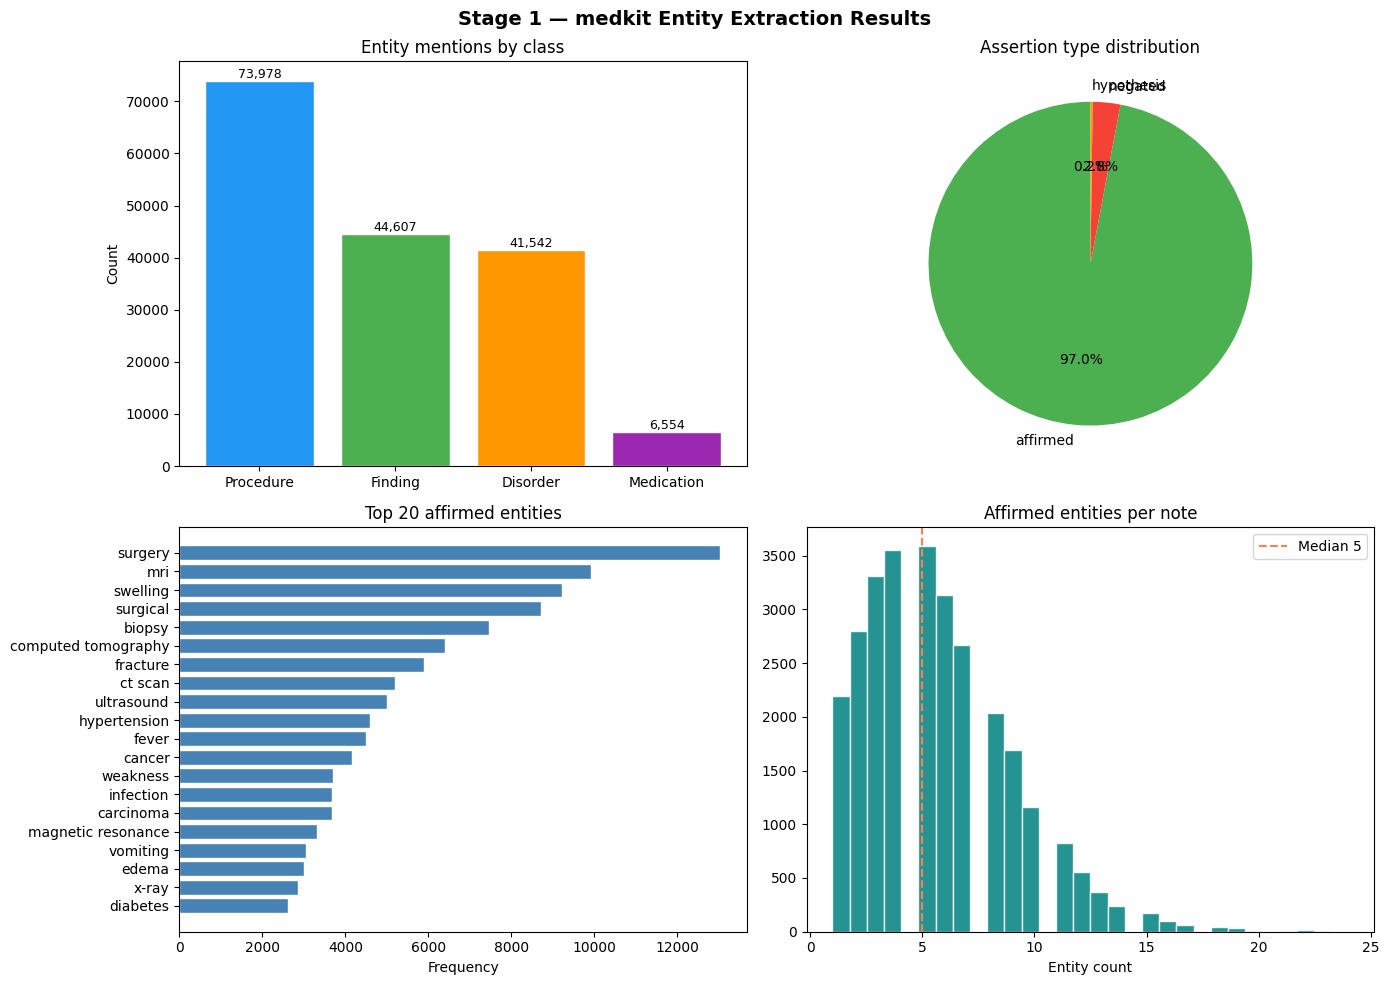

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Stage 1 — medkit Entity Extraction Results", fontsize=14, fontweight="bold")

# 7.1 Entity class distribution (all assertions)
lbl_counts = entities_df["label"].value_counts()
colors     = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]
bars = axes[0, 0].bar(lbl_counts.index, lbl_counts.values, color=colors, edgecolor="white")
for bar, val in zip(bars, lbl_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                    f"{val:,}", ha="center", va="bottom", fontsize=9)
axes[0, 0].set_title("Entity mentions by class")
axes[0, 0].set_ylabel("Count")

# 7.2 Assertion distribution
assert_counts = entities_df["assertion"].value_counts()
axes[0, 1].pie(assert_counts.values, labels=assert_counts.index, autopct="%1.1f%%",
               startangle=90, colors=["#4CAF50", "#F44336", "#FF9800"])
axes[0, 1].set_title("Assertion type distribution")

# 7.3 Top 20 most frequent affirmed entities
top20 = affirmed["text"].value_counts().head(20)
axes[1, 0].barh(top20.index[::-1], top20.values[::-1], color="steelblue", edgecolor="white")
axes[1, 0].set_title("Top 20 affirmed entities")
axes[1, 0].set_xlabel("Frequency")

# 7.4 Affirmed entities per note
per_note = affirmed.groupby("note_id").size()
axes[1, 1].hist(per_note, bins=30, color="teal", edgecolor="white", alpha=0.85)
axes[1, 1].axvline(per_note.median(), color="coral", linestyle="--",
                   label=f"Median {per_note.median():.0f}")
axes[1, 1].set_title("Affirmed entities per note")
axes[1, 1].set_xlabel("Entity count")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_entity_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Entity co-occurrence heatmap

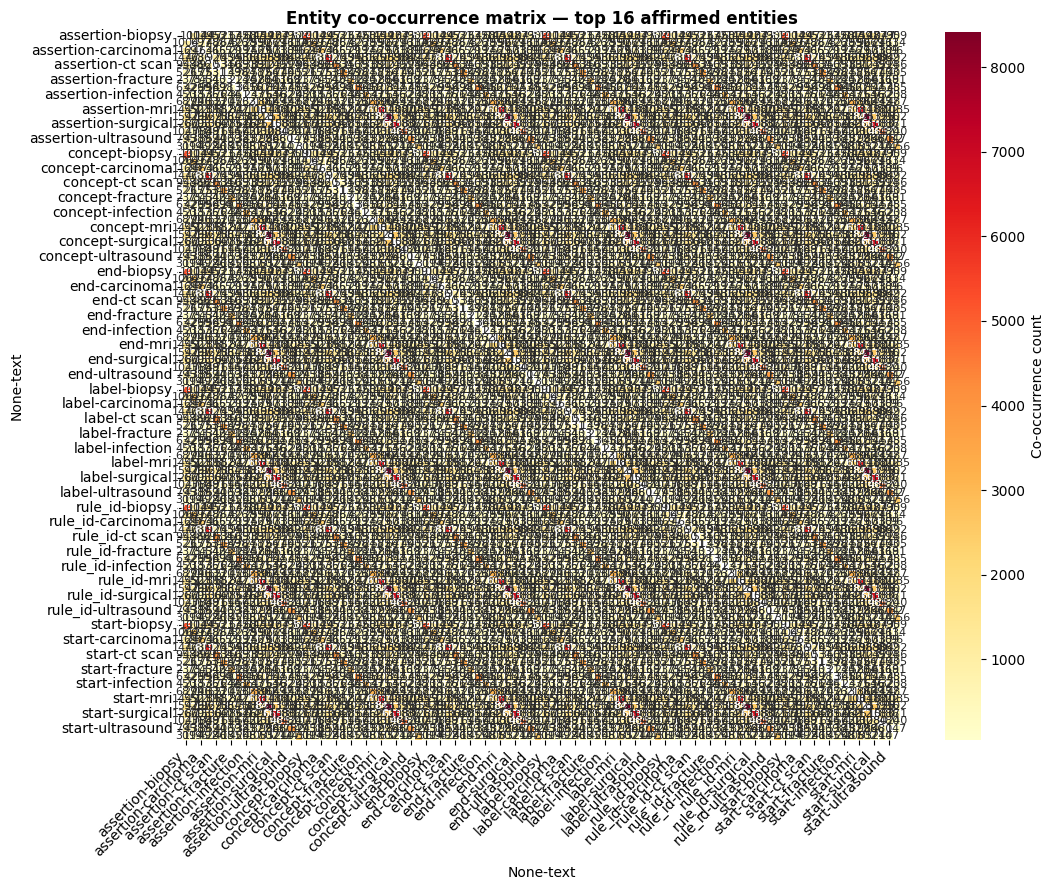

High co-occurrence pairs suggest clinical phenotype clusters (e.g., diabetes + metformin).


In [11]:
TOP_N = 16
top_entities = affirmed["text"].value_counts().head(TOP_N).index.tolist()

pivot = (
    affirmed[affirmed["text"].isin(top_entities)]
    .drop_duplicates(subset=["note_id", "text"])
    .pivot_table(index="note_id", columns="text", aggfunc=len, fill_value=0)
    .clip(upper=1)
)

cooc = pivot.T.dot(pivot)
mask = np.eye(len(cooc), dtype=bool)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cooc, mask=mask, ax=ax, cmap="YlOrRd",
            linewidths=0.4, linecolor="white",
            annot=True, fmt="d", annot_kws={"size": 8},
            cbar_kws={"label": "Co-occurrence count"})
ax.set_title(f"Entity co-occurrence matrix — top {TOP_N} affirmed entities",
             fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()

print("High co-occurrence pairs suggest clinical phenotype clusters (e.g., diabetes + metformin).")

## 9. Build the patient entity feature matrix

Aggregate **affirmed** entity mentions per note into two representations
saved for Stage 2:

| File | Description |
|---|---|
| `entity_count_matrix.csv` | raw entity count per note (note_id × entity_text) |
| `entity_tfidf_matrix.npz` | TF-IDF weighted sparse matrix |
| `entity_vocab.npy` | vocabulary array (column names) |
| `note_ids.npy` | note ID array (row index) |

In [12]:
# ── Feature matrix keyed on CANONICAL CONCEPT (normalized), not raw text ───────
# Falls back to raw text only if rule-id normalization was unavailable.
KEYCOL = "concept" if "concept" in affirmed.columns and affirmed["concept"].notna().any() else "text"
print(f"Building entity matrix on column: '{KEYCOL}'")

entity_counts = (
    affirmed
    .groupby(["note_id", KEYCOL])
    .size()
    .unstack(fill_value=0)
    .reindex(df["idx"], fill_value=0)          # align with note ordering
)

# TF-IDF weighting
tfidf     = TfidfTransformer(norm="l2", use_idf=True, smooth_idf=True)
X_tfidf   = tfidf.fit_transform(entity_counts.values)

# Persist
entity_counts.to_csv(OUTPUT_DIR / "entity_count_matrix.csv")
save_npz(str(OUTPUT_DIR / "entity_tfidf_matrix.npz"), X_tfidf)
np.save(str(OUTPUT_DIR / "entity_vocab.npy"),  np.array(entity_counts.columns.tolist()))
np.save(str(OUTPUT_DIR / "note_ids.npy"),       np.array(entity_counts.index.tolist()))

print(f"Entity feature matrix: {entity_counts.shape[0]:,} notes x {entity_counts.shape[1]:,} concepts")
print(f"  (raw distinct surface forms were: {affirmed['text'].nunique():,};"
      f" normalized concepts: {entity_counts.shape[1]:,})")
print(f"Sparsity: {(entity_counts.values == 0).sum() / entity_counts.values.size:.1%}")
print(f"\\nSaved to {OUTPUT_DIR}/")

doc_freq = (entity_counts > 0).sum().sort_values(ascending=False)
print(f"\\nTop 15 concepts by document frequency:")
print(doc_freq.head(15).to_string())


Building entity matrix on column: 'concept'
Entity feature matrix: 30,000 notes x 78 concepts
  (raw distinct surface forms were: 165; normalized concepts: 78)
Sparsity: 95.3%
\nSaved to /content/drive/MyDrive/phenoprompt/stage1_outputs/
\nTop 15 concepts by document frequency:
concept
SURG      12553
CT         9172
MRI        7405
EDEMA      6701
BX         5243
CANCER     5178
HTN        4094
US         3782
FEV        3547
FAT        3273
NV         3174
INF        2861
XR         2851
DM         2662
SOB        2627


## 10. Stage 1 summary

In [13]:
total = len(entities_df)
aff   = (entities_df.assertion == "affirmed").sum()
neg   = (entities_df.assertion == "negated").sum()
hyp   = (entities_df.assertion == "hypothesis").sum()

print("=" * 55)
print("PHENOPROMPT — STAGE 1 SUMMARY")
print("=" * 55)
print(f"  Notes processed:          {len(df):>8,}")
print(f"  Total entity mentions:    {total:>8,}")
print(f"    Affirmed:               {aff:>8,}  ({aff/total:.1%})")
print(f"    Negated:                {neg:>8,}  ({neg/total:.1%})")
print(f"    Hypothetical:           {hyp:>8,}  ({hyp/total:.1%})")
print(f"  Notes with ≥1 entity:    {affirmed['note_id'].nunique():>8,}")
print(f"  Entity vocabulary size:  {entity_counts.shape[1]:>8,}")
print(f"  Feature matrix shape:    {entity_counts.shape[0]:>5,} × {entity_counts.shape[1]}")
print("")
print("Entity class breakdown (affirmed):")
for lbl, cnt in affirmed["label"].value_counts().items():
    print(f"  {lbl:<12} {cnt:>7,}  ({cnt/aff:.1%})")
print("=" * 55)
print()
print("Stage 1 complete. Load stage1_outputs/ in Stage 2 notebook.")

PHENOPROMPT — STAGE 1 SUMMARY
  Notes processed:            30,000
  Total entity mentions:     166,681
    Affirmed:                161,715  (97.0%)
    Negated:                   4,597  (2.8%)
    Hypothetical:                369  (0.2%)
  Notes with ≥1 entity:      28,562
  Entity vocabulary size:        78
  Feature matrix shape:    30,000 × 78

Entity class breakdown (affirmed):
  Procedure     70,921  (43.9%)
  Finding       44,005  (27.2%)
  Disorder      40,301  (24.9%)
  Medication     6,488  (4.0%)

Stage 1 complete. Load stage1_outputs/ in Stage 2 notebook.
